# Improved Maximum Correlated Kurtosis Deconvolution (IMCKD)

A vibration sensor almost never sees the fault pulses themselves. The
record is closer to a **linear mixture**

$$x(t)=h(t)*s(t)+n(t),$$

where $s(t)$ is a sparse, nearly periodic train of impacts, $h(t)$
is the unknown transmission path (housing / sensor resonance), and
$n(t)$ is noise plus other rotating components.

**Blind deconvolution** learns an inverse FIR $f$ so that
$y=f*x$ looks like $s$: sharp, impulsive, repeating. Maximum
correlated kurtosis deconvolution (MCKD; McDonald, Zhao & Zuo, MSSP
2012) maximises the *correlated kurtosis* of $y$ at a lag $T$
(the fault period in samples). Classical MCKD therefore **needs** $T$
from bearing geometry and RPM. If that prior is wrong, the filter
locks onto the wrong cycle.

**IMCKD** (Miao, Zhao, Lin & Lei, MSSP 2017) estimates $T$ from the
Hilbert-envelope autocorrelation of the current output at every
iteration, rebuilds the delay tensor, and updates $f$ until both
the filter and the period settle. The MATLAB demo states the goal
explicitly: solve the **prior-period** problem in blind deconvolution.

This notebook ports ``imckd.m``. The solver is non-interactive; the
iteration traces that MATLAB drew with ``plotyy`` are returned in
``info`` and plotted here.

| | **MCKD** | **IMCKD** (this notebook) |
|---|---|---|
| Period $T$ | known prior | envelope ACF, updated every iteration |
| Criterion | correlated kurtosis of shift $M$ | same, rebuilt at the new $T$ |
| Output | inverse FIR and $y$ | FIR, $y$, and the $T$ / kurtosis trajectory |

**References**

> Y. Miao, M. Zhao, J. Lin, Y. Lei, *Application of an improved
> maximum correlated kurtosis deconvolution method for fault diagnosis
> of rolling element bearings*, Mechanical Systems and Signal
> Processing 92 (2017) 173–195.

> G. L. McDonald, Q. Zhao, M. J. Zuo, *Maximum correlated Kurtosis
> deconvolution and application on gear tooth chip fault detection*,
> Mechanical Systems and Signal Processing 33 (2012) 237–255.


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())

from pysdkit.data import load_imckd_sig1
from pysdkit.utils import (
    annotate_harmonics,
    envelope_spectrum,
    imckd,
    matlab_kurtosis,
    peak_frequency,
)

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py


## 2. What the code computes

**Correlated kurtosis.** Let $y_t$ be the current FIR output and
$y_t^{(m)}=y_{t-mT}$ its delay by $m$ periods. MCKD of shift
order $M$ maximises

$$\mathrm{CK}_M(T)=\frac{\sum_t \bigl(\prod_{m=0}^{M} y_t^{(m)}\bigr)^2}{\bigl(\sum_t y_t^2\bigr)^{M+1}}.$$

The inverse filter is obtained from a delay tensor $X_{mT}$
(Hankel-like rows of $x$ delayed by $mT$) by the same update as
original MCKD, then normalised to unit energy.

**Period from the envelope (MATLAB ``TT``).** IMCKD does *not* take
the FFT of $x$ as the period. It forms the mean-centred Hilbert
envelope

$$\tilde{e}(t)=\bigl|\mathcal{H}\{y\}(t)\bigr|-\mathrm{mean}\bigl(|\mathcal{H}\{y\}|\bigr),$$

computes the normalised autocorrelation up to lag $M=f_s$ (one
second), skips the first zero-crossing (the local correlation lobe),
and takes

$$T=\texttt{zeroposi}+\texttt{max\_position}$$

in MATLAB 1-based indices (true ACF lag of that peak is $T-2$).
That $T$ is rounded and the delay tensor is rebuilt.

The loop always runs ``term_iter`` times. The returned $y$ is the
iterate of **maximum kurtosis** (not maximum CK), matching
``imckd.m``.

These methods assume periodic *transients through a linear channel*.
They are a poor fit for smooth seasonality, random walks, or additive
AM–FM tones with no convolutional path (use STL / SST / SET / VMD
there).


## 3. MATLAB demo (``01 IMCKD/demo.m``)

Packaged ``sig1.mat``: 20001 samples at $f_s=20\,\mathrm{kHz}$.
Filter length $L=50$, shift order $M=1$, 30 iterations, $T$
estimated from the raw envelope. The MATLAB figure overlays period
harmonics of $20000/29$ samples — about **29 Hz**.


N = 20001 fs = 20000.0 fault_hz = 29.0


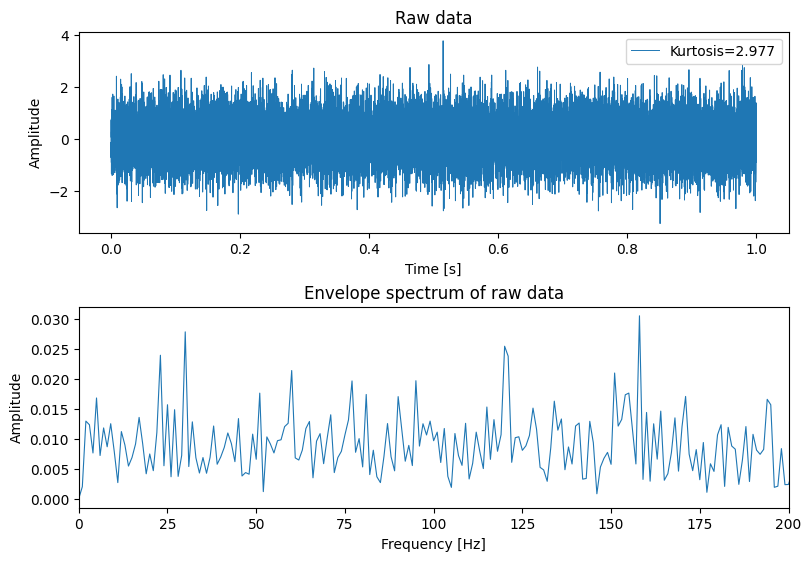

In [2]:
record = load_imckd_sig1()
x = record["signal"] - np.mean(record["signal"])
fs = float(record["fs"])
t = record["t"]
fault_hz = float(record["fault_hz"])
print("N =", x.size, "fs =", fs, "fault_hz =", fault_hz)

freq_x, spec_x = envelope_spectrum(x, fs, scale="fs")
fig, axes = plt.subplots(2, 1, figsize=(8, 5.5), constrained_layout=True)
axes[0].plot(t, x, color="C0", lw=0.7)
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Raw data")
axes[0].legend([f"Kurtosis={matlab_kurtosis(x):.3f}"], loc="upper right")
axes[1].plot(freq_x, spec_x, color="C0", lw=0.8)
axes[1].set_xlim(0, 200)
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Envelope spectrum of raw data")
plt.show()

## 4. Run IMCKD

`annotate_harmonics` marks the characteristic line and its integer
multiples on the envelope spectrum, the way Fig. 8 of the IMCKD paper
labels $f_o,\,2f_o,\,\ldots$ with arrows on each local peak.


||f|| = 1.0
best_iter = 30 final T = 667
kurtosis(y) = 4.118819177299789
envelope peak in [0, 200] Hz: 29.99850007499625


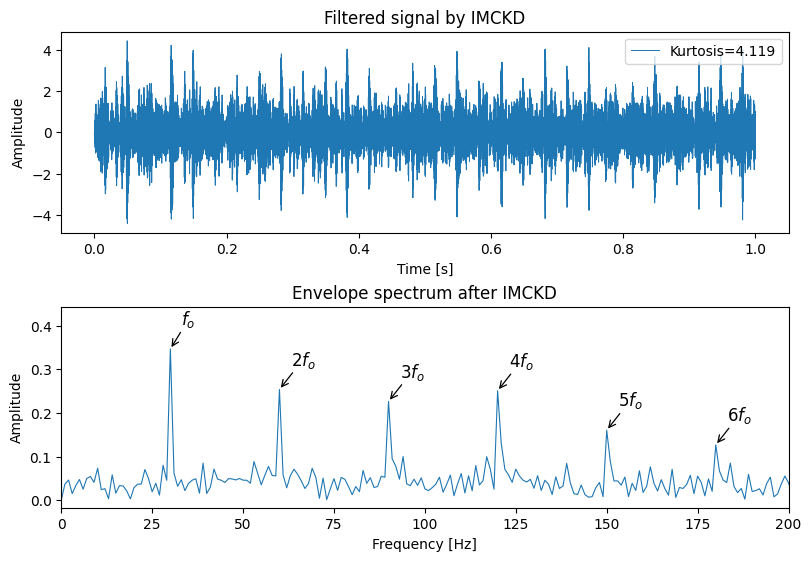

In [3]:
y, fir, info = imckd(x, fs, filter_size=50, term_iter=30, shift_order=1)
print("||f|| =", np.linalg.norm(fir))
print("best_iter =", info["best_iter"], "final T =", info["period"])
print("kurtosis(y) =", matlab_kurtosis(y))

freq_y, spec_y = envelope_spectrum(y, fs, scale="fs")
peak = peak_frequency(freq_y, spec_y, f_max=200.0)
print("envelope peak in [0, 200] Hz:", peak)

fig, axes = plt.subplots(2, 1, figsize=(8, 5.5), constrained_layout=True)
axes[0].plot(t, y, color="C0", lw=0.7)
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Filtered signal by IMCKD")
axes[0].legend([f"Kurtosis={matlab_kurtosis(y):.3f}"], loc="upper right")
axes[1].plot(freq_y, spec_y, color="C0", lw=0.8)
axes[1].set_xlim(0, 200)
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Envelope spectrum after IMCKD")
annotate_harmonics(freq_y, spec_y, fault_hz, n_harmonics=6, ax=axes[1], symbol=r"f_o")
plt.show()

## 5. Period and kurtosis versus iteration

MATLAB ``imckd`` always opened a dual-axis plot of the estimated
period (samples) and the kurtosis of $y$. The dotted guides are
integer multiples of $20000/29$ samples.


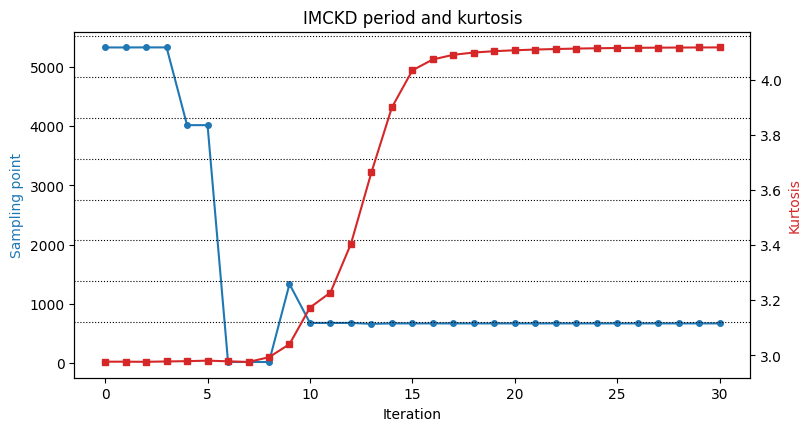

In [4]:
period_hist = np.asarray(info["period_hist"], dtype=float)
kurt_hist = np.asarray(info["kurtosis_hist"], dtype=float)
iters = np.arange(period_hist.size)

fig, ax_t = plt.subplots(figsize=(8, 4.2), constrained_layout=True)
ax_k = ax_t.twinx()
ax_t.plot(iters, period_hist, "C0-o", ms=4, label="period T")
ax_k.plot(iters, kurt_hist, "C3-s", ms=4, label="kurtosis")
ref = 20000.0 / 29.0
for k in range(1, int(np.ceil(np.max(period_hist) / ref)) + 1):
    ax_t.axhline(k * ref, color="k", ls=":", lw=0.8)
ax_t.set_xlabel("Iteration")
ax_t.set_ylabel("Sampling point", color="C0")
ax_k.set_ylabel("Kurtosis", color="C3")
ax_t.set_title("IMCKD period and kurtosis")
plt.show()